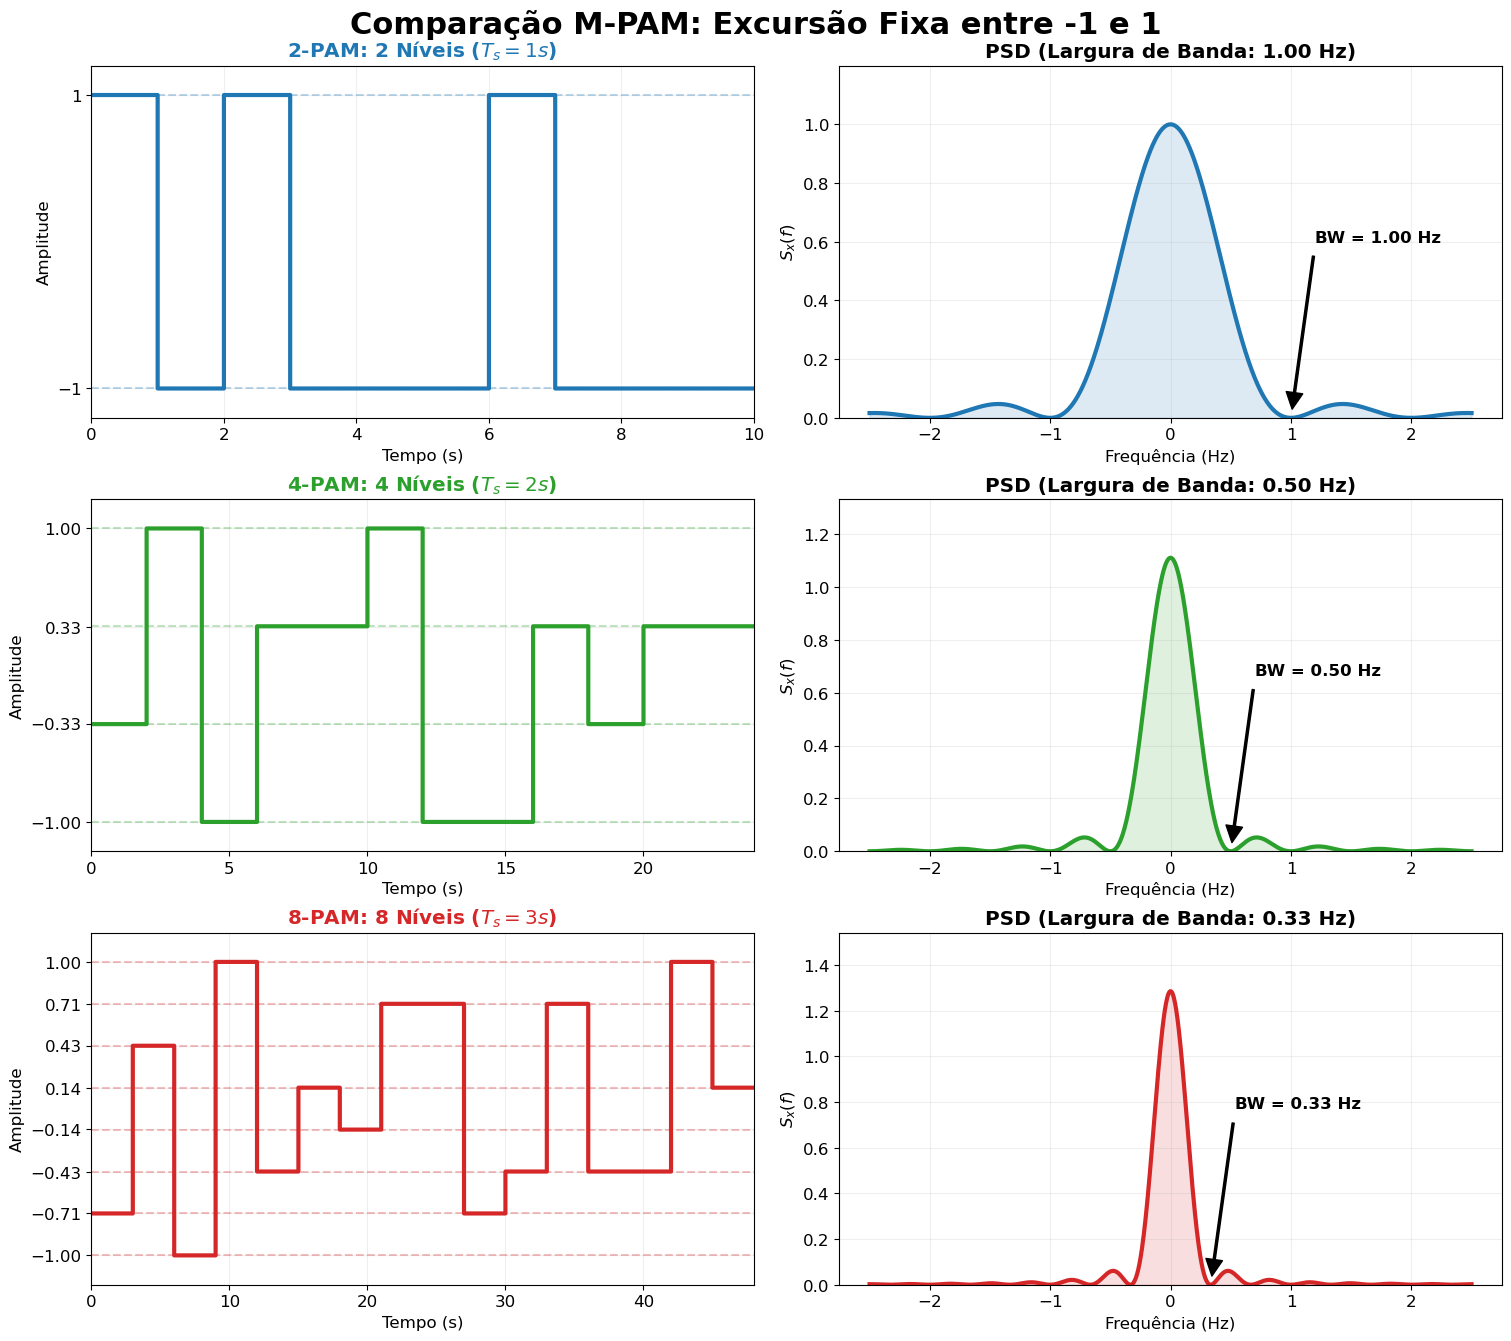

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo para slides
plt.rcParams.update({'font.size': 12, 'axes.grid': True, 'grid.alpha': 0.2})

# Parâmetros
Rb = 1.0           # Taxa de bits constante (1 bps)
fs = 200           
orders = [2, 4, 8]
colors = ['#1f77b4', '#2ca02c', '#d62728']

fig, axs = plt.subplots(3, 2, figsize=(15, 13), constrained_layout=True)
fig.suptitle('Comparação M-PAM: Excursão Fixa entre -1 e 1', 
             fontsize=22, fontweight='bold', y=1.02)

for i, M in enumerate(orders):
    k = int(np.log2(M))
    Ts = k / Rb
    
    # 1. Níveis PAM básicos: -(M-1)...(M-1)
    levels = np.arange(-(M-1), M, 2)
    
    # 2. Normalização para Excursão Fixa [-1, 1]
    scale = 1.0 / (M - 1)
    target_levels = levels * scale
    
    # 3. Sequência garantindo todos os níveis (Embaralhados + aleatórios)
    np.random.seed(42)
    # Embaralha os níveis para garantir que todos apareçam mas sem ordem de escada
    shuffled_targets = np.random.permutation(target_levels)
    actual_symbols = np.concatenate((shuffled_targets, np.random.choice(target_levels, size=8)))
    
    t_wave = np.linspace(0, len(actual_symbols) * Ts, len(actual_symbols) * fs)
    wave = np.repeat(actual_symbols, fs)
    
    # Cálculo da potência média para a PSD
    power_avg = np.mean(target_levels**2)

    # --- COLUNA 1: TEMPO (Excursão -1 a 1) ---
    for lvl in target_levels:
        axs[i, 0].axhline(lvl, color=colors[i], linestyle='--', alpha=0.3)
    
    axs[i, 0].step(t_wave, wave, where='post', color=colors[i], lw=3)
    axs[i, 0].set_title(f'{M}-PAM: {M} Níveis ($T_s = {k}s$)', fontweight='bold', color=colors[i])
    axs[i, 0].set_ylabel('Amplitude')
    axs[i, 0].set_ylim(-1.2, 1.2) 
    axs[i, 0].set_yticks(np.round(target_levels, 2))
    axs[i, 0].set_xlabel('Tempo (s)')
    axs[i, 0].set_xlim(0, t_wave[-1])

    # --- COLUNA 2: FREQUÊNCIA (PSD) ---
    f = np.linspace(-2.5, 2.5, 1000)
    # PSD: Sx(f) = (1/Ts) * |P(f)|^2 * E[A^2]
    psd = power_avg * Ts * (np.sinc(f * Ts)**2)
    
    axs[i, 1].plot(f, psd, color=colors[i], lw=3)
    axs[i, 1].fill_between(f, psd, color=colors[i], alpha=0.15)
    axs[i, 1].set_title(f'PSD (Largura de Banda: {1/Ts:.2f} Hz)', fontweight='bold')
    axs[i, 1].set_ylabel('$S_x(f)$')
    axs[i, 1].set_xlabel('Frequência (Hz)')
    
    # Ajuste do eixo Y da PSD
    axs[i, 1].set_ylim(0, max(psd)*1.2 if max(psd) > 0 else 1)
    
    null_f = 1/Ts
    axs[i, 1].annotate(f'BW = {null_f:.2f} Hz', xy=(null_f, 0), 
                       xytext=(null_f + 0.2, max(psd)*0.6),
                       arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
                       fontweight='bold')

plt.savefig('mpam_excursao_fixa_final.png', dpi=300, bbox_inches='tight')
plt.show()